### Generar sCMBs para sujetos sanos: creación dataset D201

In [2]:
import os
import glob
import numpy as np
import nibabel as nib
import json
from scipy.ndimage import binary_erosion, generate_binary_structure, rotate
from skimage.transform import downscale_local_mean
import time
import shutil
from nilearn.image import resample_to_img

In [ ]:
import pandas as pd
import numpy as np
import os

# --- PARÁMETROS DE CONFIGURACIÓN ---
INPUT_CSV = "/media/PORT-DISK/Practicas/ADNI_Final_Training_Set.csv"
OUTPUT_PLAN = "/media/PORT-DISK/Practicas/ADNI_Generation_Workplan.csv"
RANDOM_SEED = 42

# Definición de carpetas de destino (Estructura para nnU-Net o similar)
BASE_DIR = r"C:\Users\marta\Downloads\ADNI"
OUT_TRIAL_1 = os.path.join(BASE_DIR, "Trial_1_Real")
OUT_TRIAL_2 = os.path.join(BASE_DIR, "Trial_2_Synthetic")

def prepare_generation_plan():
    """
    Crea la hoja de ruta con densidades aleatorias según los rangos acordados.
    """
    if not os.path.exists(INPUT_CSV):
        print(f"Error: No se encuentra {INPUT_CSV}")
        return

    df = pd.read_csv(INPUT_CSV)
    np.random.seed(RANDOM_SEED)

    # 1. Separación de grupos
    df['Experiment_Group'] = np.where(df['Has_CMB'], 'Trial_1_Real', 'Trial_2_Synthetic')
    df['Output_Folder'] = np.where(df['Has_CMB'], OUT_TRIAL_1, OUT_TRIAL_2)
    
    # Inicializamos la columna de conteo objetivo
    df['Target_CMBs'] = 0

    # 2. Procesamiento de Negativos (Trial 2) para insertar sCMBs
    neg_mask = df['Experiment_Group'] == 'Trial_2_Synthetic'
    neg_indices = df[neg_mask].index.tolist()
    np.random.shuffle(neg_indices)

    total_neg = len(neg_indices)
    
    # Definición de tamaños de subgrupos según porcentajes
    n_clean = int(total_neg * 0.20)         # 20% -> 0 lesiones
    n_low = int(total_neg * 0.50)           # 50% -> 1-10 lesiones
    n_high = total_neg - n_clean - n_low    # 30% -> 11-30 lesiones (Resto)

    # Asignación de rangos aleatorios
    # Subgrupo Limpio (ya es 0 por defecto, pero lo explicitamos)
    idx_clean = neg_indices[:n_clean]
    
    # Subgrupo Carga Leve (1-10)
    idx_low = neg_indices[n_clean : n_clean + n_low]
    df.loc[idx_low, 'Target_CMBs'] = np.random.randint(1, 11, size=len(idx_low))
    df.loc[idx_low, 'Load_Category'] = 'Low (1-10)'

    # Subgrupo Carga Alta (11-30)
    idx_high = neg_indices[n_clean + n_low:]
    df.loc[idx_high, 'Target_CMBs'] = np.random.randint(11, 31, size=len(idx_high))
    df.loc[idx_high, 'Load_Category'] = 'High (11-30)'
    
    df.loc[idx_clean, 'Load_Category'] = 'Clean (0)'

    # 3. Metadatos de control
    df['Processing_Status'] = 'Pending'
    df.loc[df['Experiment_Group'] == 'Trial_1_Real', 'Load_Category'] = 'Real_Findings'

    # 4. Guardado
    df.to_csv(OUTPUT_PLAN, index=False)

    # --- VERIFICACIÓN DE RESULTADOS ---
    print("="*60)
    print("PARTE I: PLAN DE TRABAJO GENERADO CORRECTAMENTE")
    print("="*60)
    print(f"Total sujetos en el plan: {len(df)}")
    print("\nDistribución estocástica en el grupo Sintético (Trial 2):")
    summary = df[df['Experiment_Group'] == 'Trial_2_Synthetic']['Load_Category'].value_counts()
    print(summary)
    
    print("\nEjemplo de los primeros sujetos sintéticos y su carga asignada:")
    print(df[df['Experiment_Group'] == 'Trial_2_Synthetic'][['LONI_IMG_ID_STR', 'Target_CMBs', 'Load_Category']].head(10))
    print(f"\nArchivo guardado: {OUTPUT_PLAN}")

if __name__ == "__main__":
    prepare_generation_plan()

PARTE I: PLAN DE TRABAJO GENERADO CORRECTAMENTE
Total sujetos en el plan: 500

Distribución estocástica en el grupo Sintético (Trial 2):
Load_Category
Low (1-10)      125
High (11-30)     75
Clean (0)        50
Name: count, dtype: int64

Ejemplo de los primeros sujetos sintéticos y su carga asignada:
    LONI_IMG_ID_STR  Target_CMBs Load_Category
250         I246686            7    Low (1-10)
251        I1590180           18  High (11-30)
252        I1196222            6    Low (1-10)
253        I1444355            7    Low (1-10)
254         I310607            8    Low (1-10)
255         I589612            6    Low (1-10)
256        I1435738            0     Clean (0)
257        I1296789           18  High (11-30)
258        I1207296           12  High (11-30)
259         I382431            0     Clean (0)

Archivo guardado: C:\Users\marta\Downloads\ADNI_Generation_Workplan.csv


In [25]:
import os
import json
import glob
import numpy as np
import nibabel as nib
import pandas as pd
from scipy.ndimage import gaussian_filter, rotate, binary_dilation
from skimage.transform import downscale_local_mean
from nilearn.image import resample_to_img

# ==========================================
# 1. CONFIGURACIÓN DE RUTAS Y CONSTANTES
# ==========================================
# Rutas de entrada
INPUT_ROOT_DIR = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/ADNI/workdir_ADNI_subset/raw/negatives"
SEG_DIR = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/ADNI/workdir_ADNI_subset/synthseg_segmentations"
WORKPLAN_CSV = "/media/PORT-DISK/Practicas/ADNI_Generation_Workplan.csv"

# Configuración nnU-Net v2
DATASET_ID = "201"
DATASET_NAME = f"Dataset{DATASET_ID}_SyntheticCMB"
NNUNET_RAW_DIR = "/media/PORT-DISK/Practicas/nnUNet_raw_ADNI"
OUTPUT_DIR = os.path.join(NNUNET_RAW_DIR, DATASET_NAME)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ==========================================
# 2. MOTOR REFINADO (v8.2)
# ==========================================
def generate_momeni_gaussian_refined(target_volume_mm3, voxel_size_mm, oversample=10):
    radius_bloom = np.cbrt((3 * target_volume_mm3) / (4 * np.pi))
    sigma_t_mm = radius_bloom / 1.5 
    
    sigma_x_mm = sigma_t_mm * np.random.uniform(0.7, 1.3)
    sigma_y_mm = sigma_t_mm * np.random.uniform(0.7, 1.3)
    sigma_z_mm = (sigma_t_mm**3) / (sigma_x_mm * sigma_y_mm)

    hr_vx_size = np.array(voxel_size_mm) / oversample
    sx, sy, sz = sigma_x_mm/hr_vx_size[0], sigma_y_mm/hr_vx_size[1], sigma_z_mm/hr_vx_size[2]
    
    grid_size = int(max(sx, sy, sz) * 5) + 1
    if grid_size % 2 == 0: grid_size += 1
    
    coords = [np.arange(grid_size) - (grid_size//2) for _ in range(3)]
    xx, yy, zz = np.meshgrid(*coords, indexing='ij')
    xx, yy, zz = xx.astype(float), yy.astype(float), zz.astype(float)

    deform = 0.25
    xx += deform * gaussian_filter(np.random.normal(0, 1, xx.shape), sigma=2)
    yy += deform * gaussian_filter(np.random.normal(0, 1, yy.shape), sigma=2)
    zz += deform * gaussian_filter(np.random.normal(0, 1, zz.shape), sigma=2)

    # 1. Generamos la irregularidad (Ruggedness)
    # --- DEFINICIÓN DE RANGOS INTERNOS (Added by me) ---
    # exponent: controla la nitidez (1.5 = gaussiano suave, 3.0 = brusco/mordisco)
    exponent = np.random.uniform(1.5, 3.0)
    # ruggedness: controla la irregularidad del borde (0.1 = circular, 0.25 = muy sucio)
    ruggedness = np.random.uniform(0.1, 0.25)

    # Creamos nubes de ruido para deformar el borde de forma orgánica
    jitter = gaussian_filter(np.random.normal(0, 1, xx.shape), sigma=1.2)
    jitter = (jitter / (np.max(np.abs(jitter)) + 1e-8)) * ruggedness 

    # 2. Calculamos el radio PERTURBADO
    # r ya no es un círculo perfecto gracias al (1 + jitter)
    r = np.sqrt((xx/sx)**2 + (yy/sy)**2 + (zz/(sz*0.6))**2)
    r_rugged = r * (1 + jitter)

    # 3. Aplicamos la caída brusca (Super-Gaussiana)
    # Usar exponent entre 2.5 y 4.0 para eliminar la "onda"
    gaussian = np.exp(-(r_rugged**exponent))
    
    img_rot = rotate(gaussian, np.random.uniform(-30,30), axes=(0,1), reshape=False, order=1)
    img_rot = rotate(img_rot, np.random.uniform(-30,30), axes=(1,2), reshape=False, order=1)
    
    low_res = downscale_local_mean(img_rot, (oversample, oversample, oversample))
    return low_res / (low_res.max() + 1e-8)

def implant_and_label_REFINED(image_data, label_data, center, volume_mm3, voxel_dims, strength):
    x, y, z = center
    lesion_pattern = generate_momeni_gaussian_refined(volume_mm3, voxel_dims, oversample=10)
    
    p_shape = lesion_pattern.shape
    dx, dy, dz = p_shape[0]//2, p_shape[1]//2, p_shape[2]//2
    x_s, x_e = x - dx, x - dx + p_shape[0]
    y_s, y_e = y - dy, y - dy + p_shape[1]
    z_s, z_e = z - dz, z - dz + p_shape[2]
    
    if x_s < 0 or x_e > image_data.shape[0] or y_s < 0 or y_e > image_data.shape[1] or z_s < 0 or z_e > image_data.shape[2]:
        return image_data, label_data
    
    roi_img = image_data[x_s:x_e, y_s:y_e, z_s:z_e]
    if roi_img.shape != lesion_pattern.shape:
        lesion_pattern = lesion_pattern[:roi_img.shape[0], :roi_img.shape[1], :roi_img.shape[2]]
    
    alpha = lesion_pattern * strength
    micro_noise = gaussian_filter(np.random.normal(0, 1, alpha.shape), sigma=0.5)
    micro_noise = (micro_noise - micro_noise.min()) / (micro_noise.max() - micro_noise.min() + 1e-8)
    alpha = alpha * (0.8 + 0.3 * micro_noise)
    alpha = np.clip(alpha, 0, 1)
    
    image_data[x_s:x_e, y_s:y_e, z_s:z_e] = (roi_img * (1 - alpha) + roi_img * 0.15 * alpha)
    lesion_mask_binary = (lesion_pattern > 0.45).astype(np.uint8)
    label_data[x_s:x_e, y_s:y_e, z_s:z_e] = np.maximum(label_data[x_s:x_e, y_s:y_e, z_s:z_e], lesion_mask_binary)
    
    return image_data, label_data

def get_segmentation_sampling_mask_REFINED(image_path, img_shape):
    filename = os.path.basename(image_path)
    seg_path = os.path.join(SEG_DIR, filename.replace('.nii.gz', '_segmentation.nii.gz'))
    img_nii = nib.load(image_path)
    seg_nii = nib.load(seg_path)
    seg_data = resample_to_img(seg_nii, img_nii, interpolation='nearest').get_fdata().astype(int)

    masks = {
        'cortex': np.isin(seg_data, list(range(1000, 3000))),
        'wm': np.isin(seg_data, [2, 41]),
        'dgm': np.isin(seg_data, [10, 49, 11, 50, 12, 51, 13, 52, 17, 53, 18, 54])
    }
    
    dilated_cortex = binary_dilation(masks['cortex'], iterations=2)
    border_zone = dilated_cortex & (seg_data == 24)
    
    weight_map = np.zeros(img_shape, dtype=float)
    target_weights = {'cortex': 0.40, 'border': 0.15, 'wm': 0.35, 'dgm': 0.10}
    masks['border'] = border_zone

    for region, weight in target_weights.items():
        n = np.sum(masks[region])
        if n > 0: weight_map[masks[region]] = weight / n

    valid_indices = np.argwhere(weight_map > 0)
    probs = weight_map[weight_map > 0]
    return valid_indices, probs / probs.sum()

In [26]:
# ==========================================
# 3. EJECUCIÓN DEL BUCLE MASIVO
# ==========================================
def run_massive_pipeline():
    for folder in ["imagesTr", "labelsTr", "imagesTs", "labelsTs"]:
        os.makedirs(os.path.join(OUTPUT_DIR, folder), exist_ok=True)

    df_workplan = pd.read_csv(WORKPLAN_CSV)
    df_syn = df_workplan[df_workplan['Experiment_Group'] == 'Trial_2_Synthetic'].reset_index(drop=True)
    
    # Split 80/20 sobre los 250 sujetos
    num_train = 200

    for idx, row in df_syn.iterrows():
        split = "Tr" if idx < num_train else "Ts"
        case_id = f"SCMB_{idx+1:03d}"
        subject_id = row['LONI_IMG_ID_STR']
        num_lesions = int(row['Target_CMBs'])

        match = glob.glob(os.path.join(INPUT_ROOT_DIR, f"*{subject_id}*.nii.gz"))
        if not match: continue
        
        file_path = match[0]
        print(f"[{idx+1}/250] {case_id} | sCMB: {num_lesions} | Split: {split}")

        try:
            nii = nib.load(file_path)
            data_img = nii.get_fdata().astype(float)
            data_label = np.zeros(data_img.shape, dtype=np.uint8)
            voxel_dims = nii.header.get_zooms()[:3]

            if num_lesions > 0:
                valid_coords, probs = get_segmentation_sampling_mask_REFINED(file_path, data_img.shape)
                n_implant = min(len(valid_coords), num_lesions) 
                selected_indices = np.random.choice(len(valid_coords), size=n_implant, replace=False, p=probs)
                
                for c_idx in selected_indices:
                    # Volumen: mm3 (basado en media 110.8 mm3 de ADNI)
                    vol_mm3 = np.random.triangular(40.0, 110.0, 250.0)
                    str_rnd = np.random.uniform(0.75, 0.98)
                    data_img, data_label = implant_and_label_REFINED(data_img, data_label, valid_coords[c_idx], vol_mm3, voxel_dims, str_rnd)

            # Guardado nnU-Net v2
            nib.save(nib.Nifti1Image(data_img, nii.affine, nii.header), 
                     os.path.join(OUTPUT_DIR, f"images{split}", f"{case_id}_0000.nii.gz"))
            nib.save(nib.Nifti1Image(data_label, nii.affine, nii.header), 
                     os.path.join(OUTPUT_DIR, f"labels{split}", f"{case_id}.nii.gz"))

        except Exception as e:
            print(f"  Error en {case_id}: {e}")

    # Generación de dataset.json
    json_dict = {
        "channel_names": {"0": "T2*"},
        "labels": {"background": 0, "CMB": 1},
        "numTraining": num_train,
        "file_ending": ".nii.gz",
        "name": DATASET_NAME,
        "reference": "Refined Momeni v8.2",
        "description": "250 scans (80/20 split). 20% Clean, 50% Low, 30% High. Border expansion included."
    }
    with open(os.path.join(OUTPUT_DIR, "dataset.json"), 'w') as f:
        json.dump(json_dict, f, indent=4)

if __name__ == "__main__":
    run_massive_pipeline()

[1/250] SCMB_001 | sCMB: 7 | Split: Tr
[2/250] SCMB_002 | sCMB: 18 | Split: Tr
[3/250] SCMB_003 | sCMB: 6 | Split: Tr
[4/250] SCMB_004 | sCMB: 7 | Split: Tr
[5/250] SCMB_005 | sCMB: 8 | Split: Tr
[6/250] SCMB_006 | sCMB: 6 | Split: Tr
[7/250] SCMB_007 | sCMB: 0 | Split: Tr
[8/250] SCMB_008 | sCMB: 18 | Split: Tr
[9/250] SCMB_009 | sCMB: 12 | Split: Tr
[10/250] SCMB_010 | sCMB: 0 | Split: Tr
[11/250] SCMB_011 | sCMB: 0 | Split: Tr
[12/250] SCMB_012 | sCMB: 5 | Split: Tr
[13/250] SCMB_013 | sCMB: 3 | Split: Tr
[14/250] SCMB_014 | sCMB: 29 | Split: Tr
[15/250] SCMB_015 | sCMB: 26 | Split: Tr
[16/250] SCMB_016 | sCMB: 0 | Split: Tr
[17/250] SCMB_017 | sCMB: 0 | Split: Tr
[18/250] SCMB_018 | sCMB: 16 | Split: Tr
[19/250] SCMB_019 | sCMB: 0 | Split: Tr
[20/250] SCMB_020 | sCMB: 0 | Split: Tr
[21/250] SCMB_021 | sCMB: 24 | Split: Tr
[22/250] SCMB_022 | sCMB: 29 | Split: Tr
[23/250] SCMB_023 | sCMB: 2 | Split: Tr
[24/250] SCMB_024 | sCMB: 6 | Split: Tr
[25/250] SCMB_025 | sCMB: 0 | Split: Tr
[

In [27]:
import pandas as pd
df = pd.read_csv("/media/PORT-DISK/Practicas/ADNI_Generation_Workplan.csv")
df_syn = df[df['Experiment_Group'] == 'Trial_2_Synthetic'].reset_index(drop=True)
# El índice 206 corresponde al caso SCMB_207
missing_subject = df_syn.iloc[206]
print(f"El sujeto que falta es: {missing_subject['LONI_IMG_ID_STR']}")

El sujeto que falta es: I1487250


In [28]:
import os
import numpy as np
import nibabel as nib
import pandas as pd
from scipy.ndimage import gaussian_filter, rotate, binary_dilation
from skimage.transform import downscale_local_mean

# --- CONFIGURACIÓN ---
TARGET_ID = "I1487250"
CASE_ID = "SCMB_207"
WORKPLAN_CSV = "/media/PORT-DISK/Practicas/ADNI_Generation_Workplan.csv"
INPUT_ROOT_DIR = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/ADNI/workdir_ADNI_subset/raw/negatives"
OUTPUT_DIR = "/media/PORT-DISK/Practicas/nnUNet_raw_ADNI/Dataset201_SyntheticCMB"

def fix_missing_case_v3():
    df = pd.read_csv(WORKPLAN_CSV)
    row = df[df['LONI_IMG_ID_STR'] == TARGET_ID].iloc[0]
    num_lesions = int(row['Target_CMBs'])
    split = "Ts" 

    match = [f for f in os.listdir(INPUT_ROOT_DIR) if TARGET_ID in f and f.endswith(".nii.gz")]
    file_path = os.path.join(INPUT_ROOT_DIR, match[0])

    print(f"Reparando {TARGET_ID}...")
    nii = nib.load(file_path)
    data_raw = nii.get_fdata().astype(float)

    # --- SOLUCIÓN AL BROADCAST ERROR ---
    # Si la imagen tiene 4 dimensiones (x, y, z, t), nos quedamos con la primera t=0
    if data_raw.ndim == 4:
        print(f"  Detectadas 4D: {data_raw.shape}. Colapsando a 3D (t=0)...")
        data_img = data_raw[:, :, :, 0]
    else:
        data_img = data_raw

    data_label = np.zeros(data_img.shape, dtype=np.uint8)
    voxel_dims = nii.header.get_zooms()[:3]

    if num_lesions > 0:
        # Importante: pasar data_img.shape ya colapsado a 3D
        valid_coords, probs = get_segmentation_sampling_mask_REFINED(file_path, data_img.shape)
        indices = np.random.choice(len(valid_coords), size=min(len(valid_coords), num_lesions), replace=False, p=probs)
        
        for c_idx in indices:
            # Aseguramos que la coordenada sea 3D
            coord_3d = valid_coords[c_idx][:3]
            vol_mm3 = np.random.triangular(40.0, 110.0, 250.0)
            str_rnd = np.random.uniform(0.75, 0.98)
            
            data_img, data_label = implant_and_label_REFINED(
                data_img, data_label, coord_3d, vol_mm3, voxel_dims, str_rnd
            )

    # Guardado como 3D estricto
    out_img_path = os.path.join(OUTPUT_DIR, f"images{split}", f"{CASE_ID}_0000.nii.gz")
    out_lbl_path = os.path.join(OUTPUT_DIR, f"labels{split}", f"{CASE_ID}.nii.gz")

    # Creamos un nuevo Nifti 3D
    # Usamos el affine original, pero el header debe actualizarse al nuevo shape 3D
    new_nii = nib.Nifti1Image(data_img, nii.affine, nii.header)
    new_nii.header.set_data_shape(data_img.shape)
    
    nib.save(new_nii, out_img_path)
    nib.save(nib.Nifti1Image(data_label, nii.affine, nii.header), out_lbl_path)
    
    print(f"¡CONSEGUIDO! Caso {CASE_ID} guardado como volumen 3D único.")

if __name__ == "__main__":
    fix_missing_case_v3()

Reparando I1487250...
  Detectadas 4D: (256, 256, 44, 12). Colapsando a 3D (t=0)...
¡CONSEGUIDO! Caso SCMB_207 guardado como volumen 3D único.


In [30]:
import pandas as pd
import os

# Rutas
PLAN_CSV = "/media/PORT-DISK/Practicas/ADNI_Final_Training_Set.csv"
MAPPING_OUTPUT = "/media/PORT-DISK/Practicas/Dataset_Mapping_Table.csv"

def generate_mapping_table():
    df = pd.read_csv(PLAN_CSV)
    mapping_data = []

    # Mapeo para Trial 1 (Reales)
    df_pos = df[df['Has_CMB'] == True].reset_index(drop=True)
    for idx, row in df_pos.iterrows():
        mapping_data.append({
            'nnUNet_ID': f"RCMB_{idx+1:03d}",
            'Original_ADNI_ID': row['LONI_IMG_ID_STR'],
            'Group': 'Real_Positive'
        })

    # Mapeo para Trial 2 (Sintéticos)
    df_neg = df[df['Has_CMB'] == False].reset_index(drop=True)
    for idx, row in df_neg.iterrows():
        mapping_data.append({
            'nnUNet_ID': f"SCMB_{idx+1:03d}",
            'Original_ADNI_ID': row['LONI_IMG_ID_STR'],
            'Group': 'Synthetic_Negative'
        })

    mapping_df = pd.DataFrame(mapping_data)
    mapping_df.to_csv(MAPPING_OUTPUT, index=False)
    print(f"Tabla de mapeo generada en: {MAPPING_OUTPUT}")

if __name__ == "__main__":
    generate_mapping_table()

Tabla de mapeo generada en: /media/PORT-DISK/Practicas/Dataset_Mapping_Table.csv


## Visualización


Caso: SCMB_144 | Lesión en (np.int64(105), np.int64(169), np.int64(21))


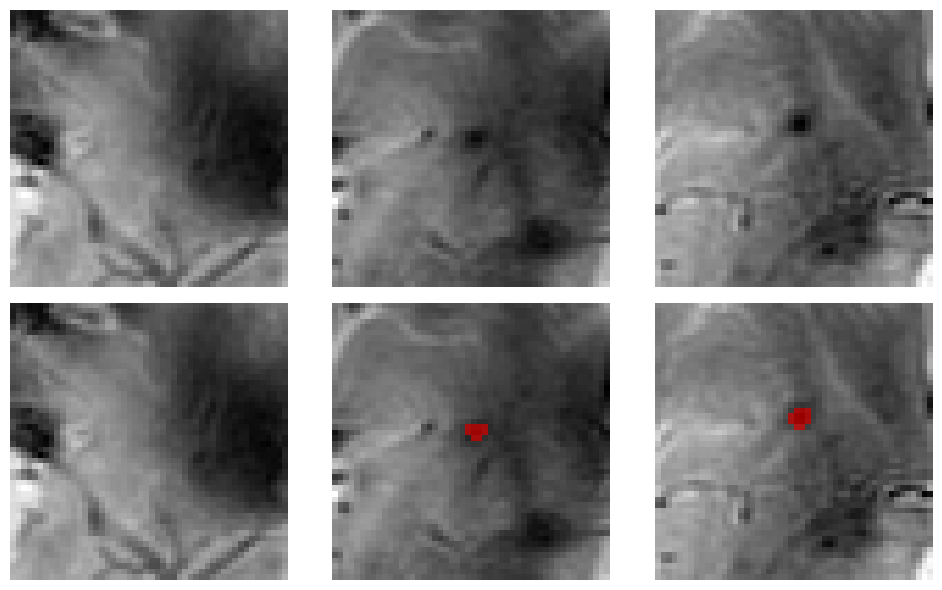


Caso: SCMB_014 | Lesión en (np.int64(151), np.int64(145), np.int64(23))


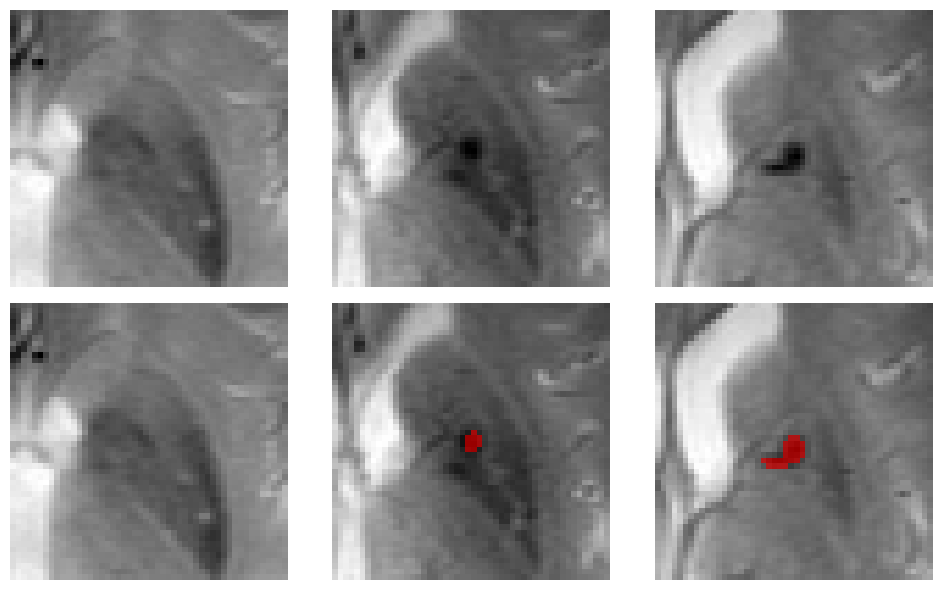


Caso: SCMB_165 | Lesión en (np.int64(99), np.int64(133), np.int64(18))


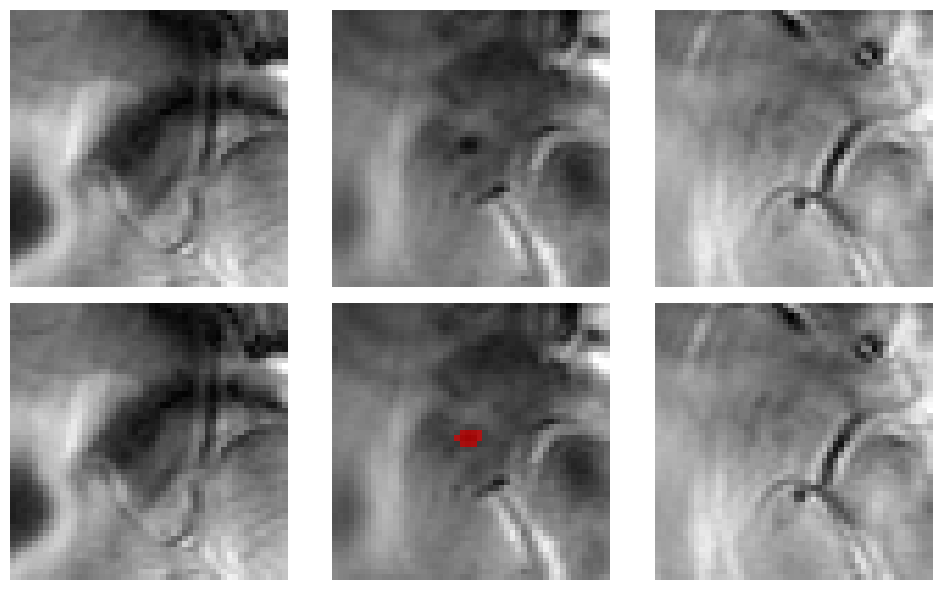


Caso: SCMB_148 | Lesión en (np.int64(100), np.int64(151), np.int64(27))


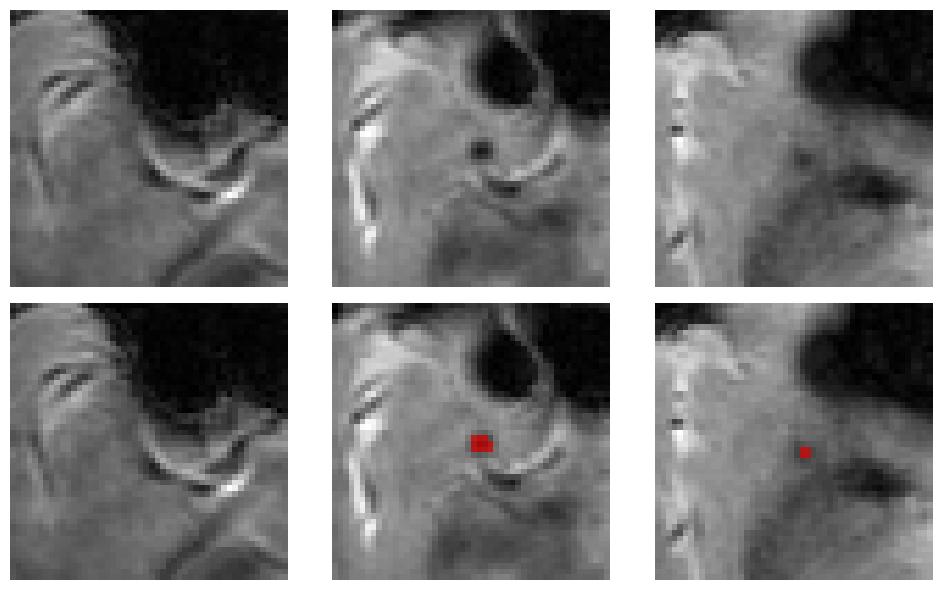


Caso: SCMB_135 | Lesión en (np.int64(172), np.int64(104), np.int64(16))


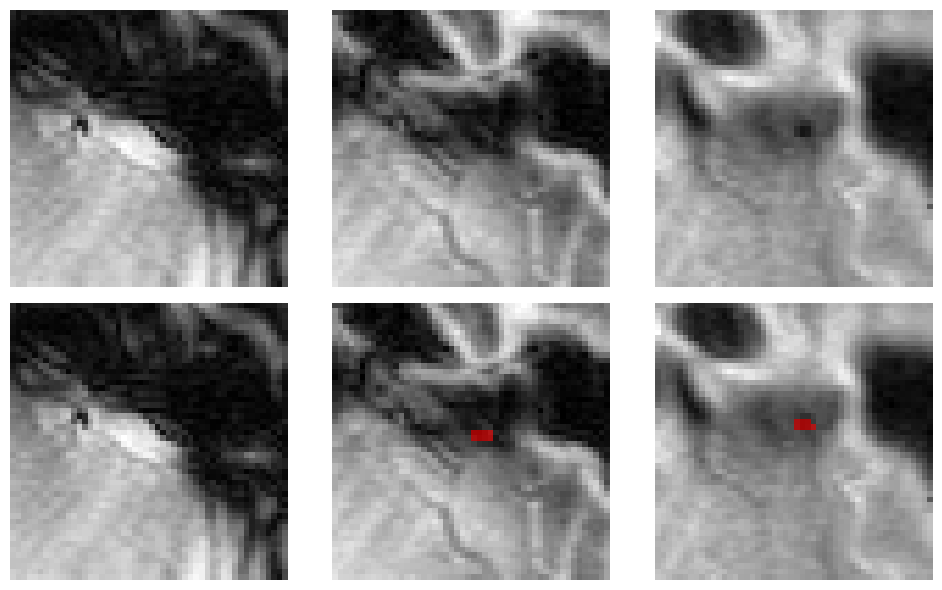


Caso: SCMB_067 | Lesión en (np.int64(120), np.int64(46), np.int64(34))


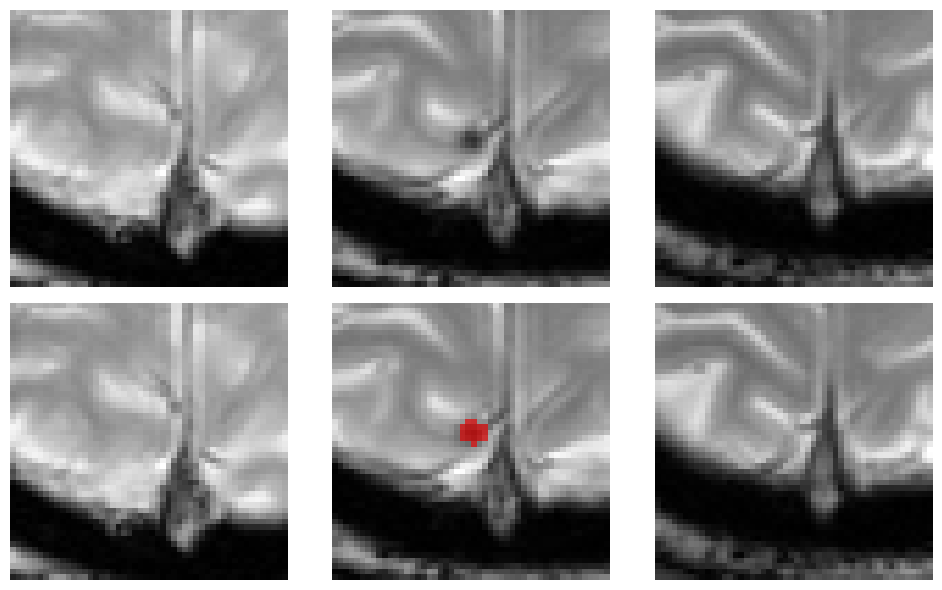


Caso: SCMB_062 | Lesión en (np.int64(152), np.int64(58), np.int64(28))


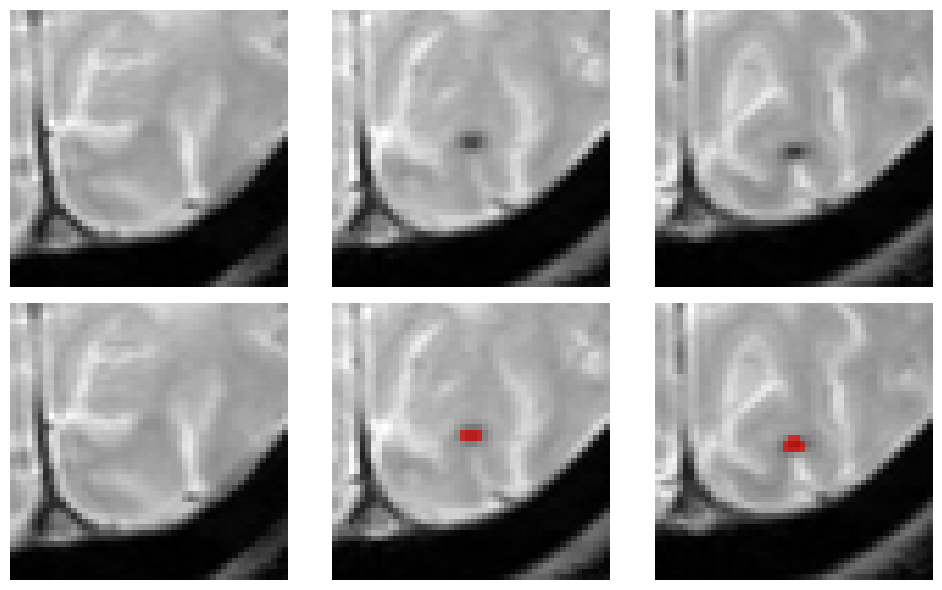


Caso: SCMB_076 | Lesión en (np.int64(111), np.int64(56), np.int64(11))


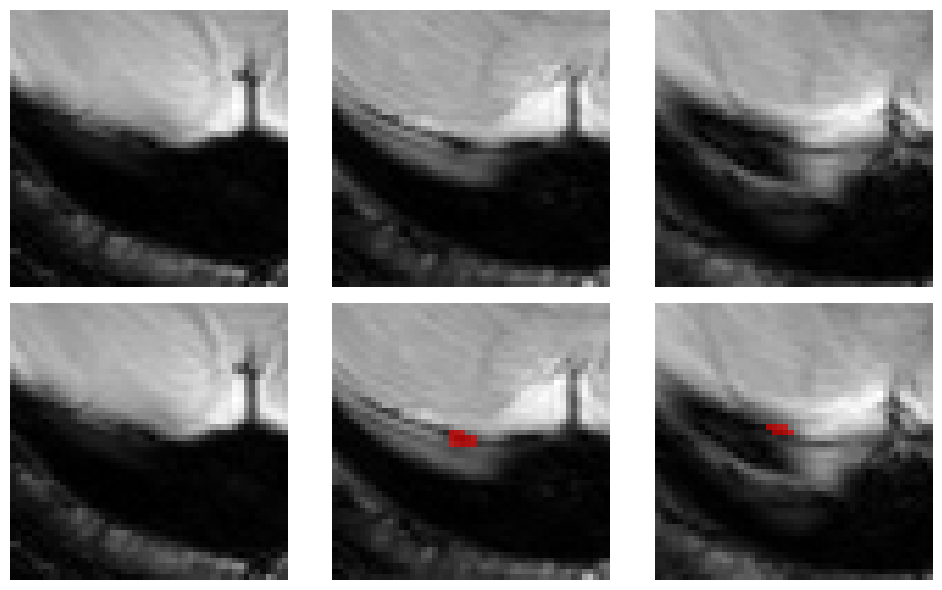


Caso: SCMB_137 | Lesión en (np.int64(158), np.int64(125), np.int64(40))


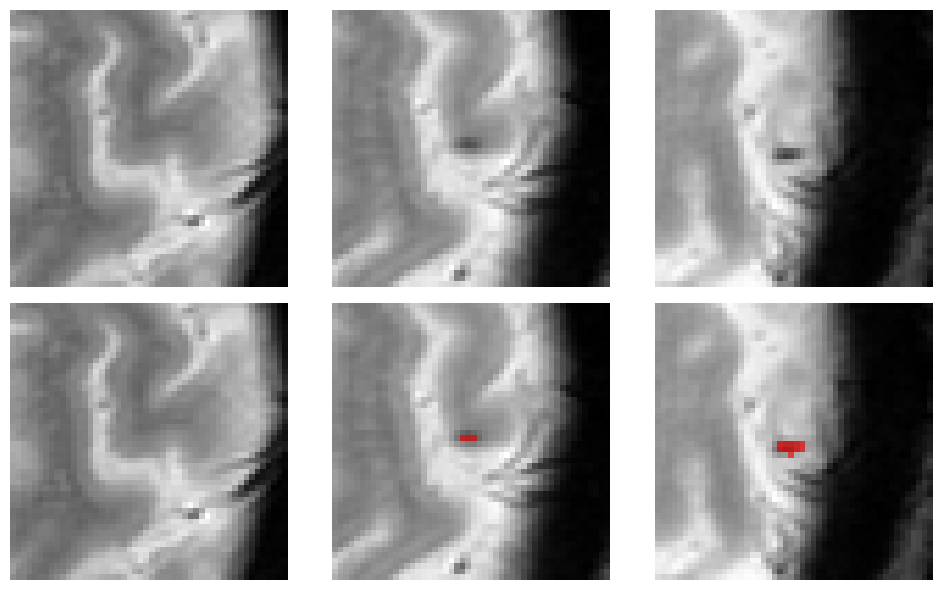


Caso: SCMB_200 | Lesión en (np.int64(189), np.int64(107), np.int64(33))


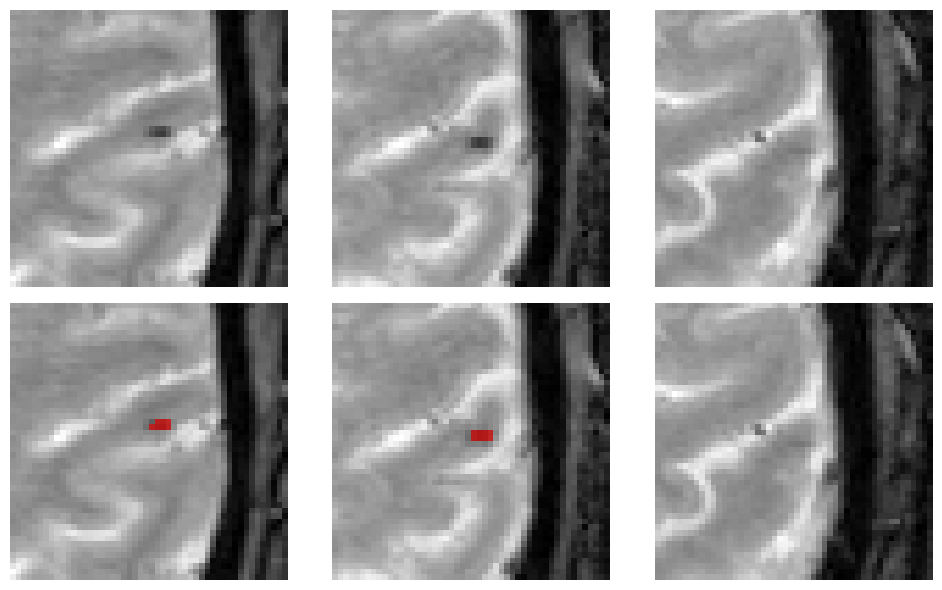


Caso: SCMB_187 | Lesión en (np.int64(77), np.int64(100), np.int64(27))


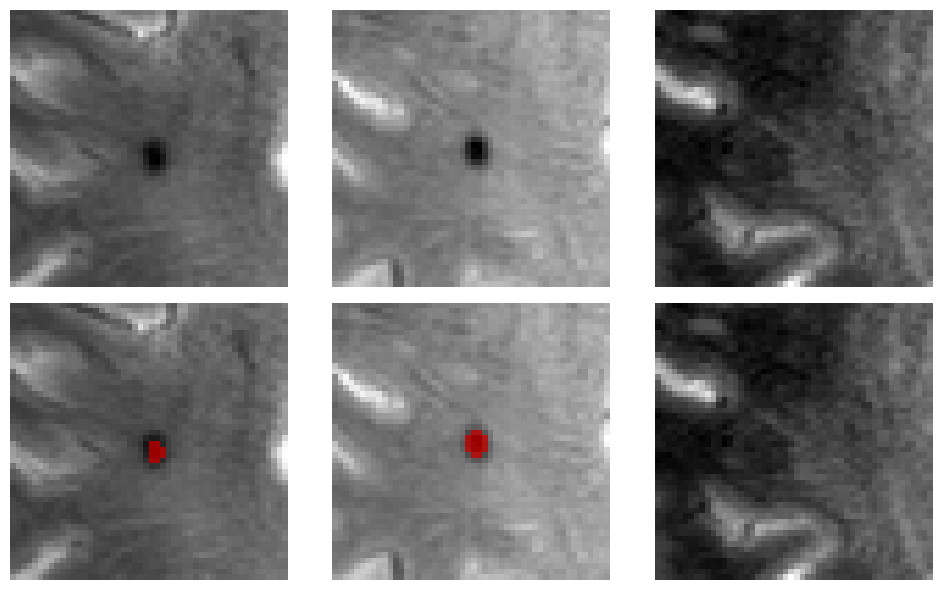


Caso: SCMB_168 | Lesión en (np.int64(85), np.int64(127), np.int64(30))


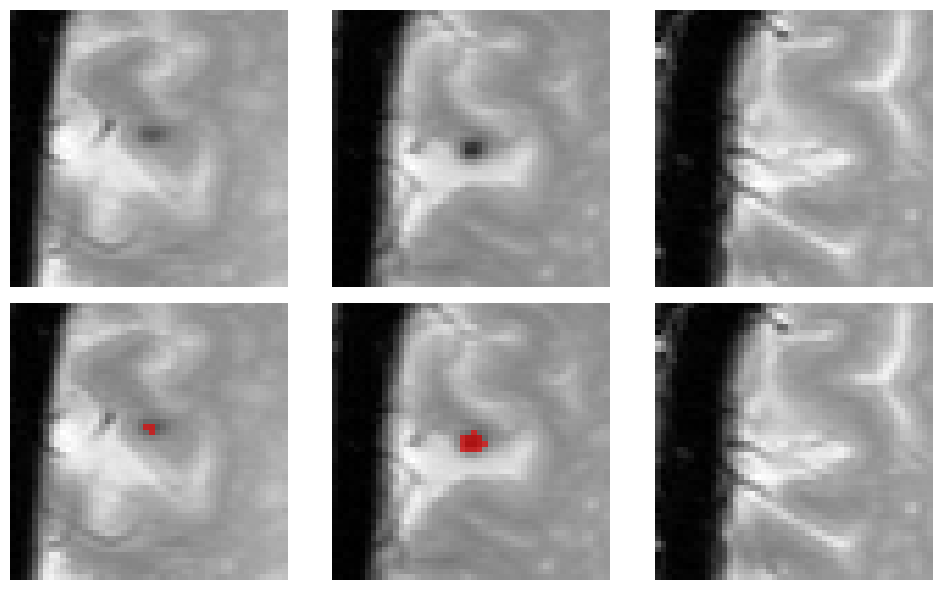


Caso: SCMB_117 | Lesión en (np.int64(82), np.int64(142), np.int64(24))


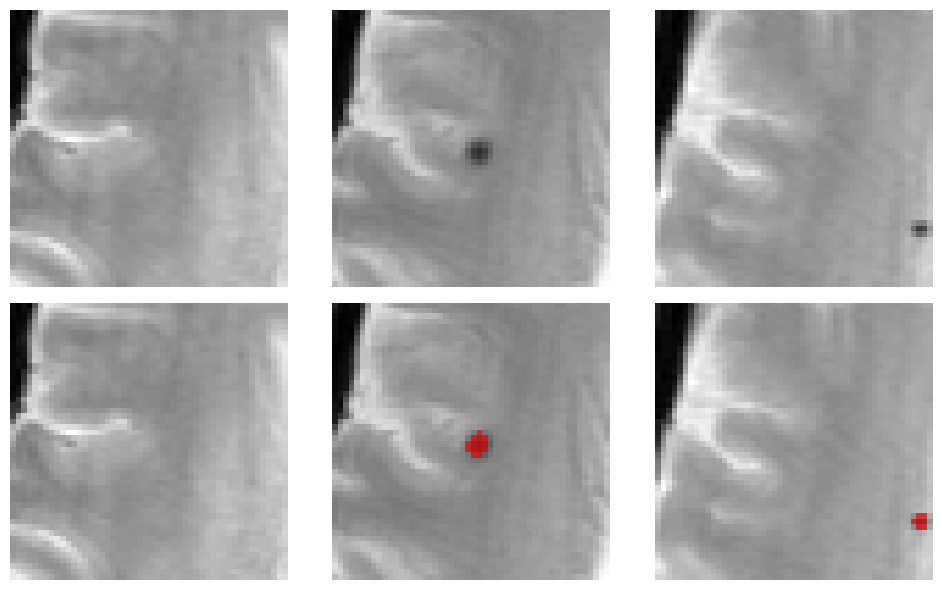


Caso: SCMB_124 | Lesión en (np.int64(75), np.int64(101), np.int64(17))


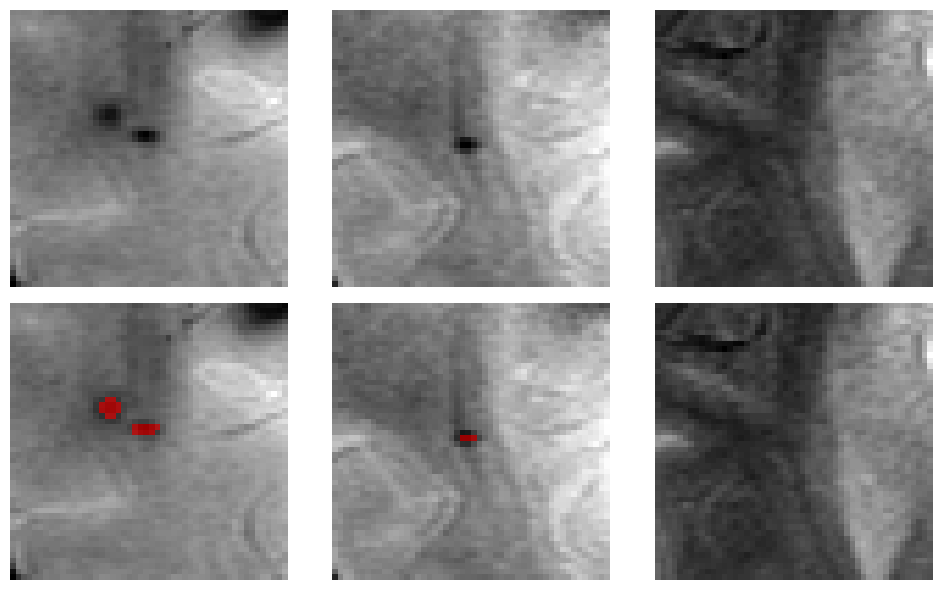


Caso: SCMB_065 | Lesión en (np.int64(131), np.int64(66), np.int64(28))


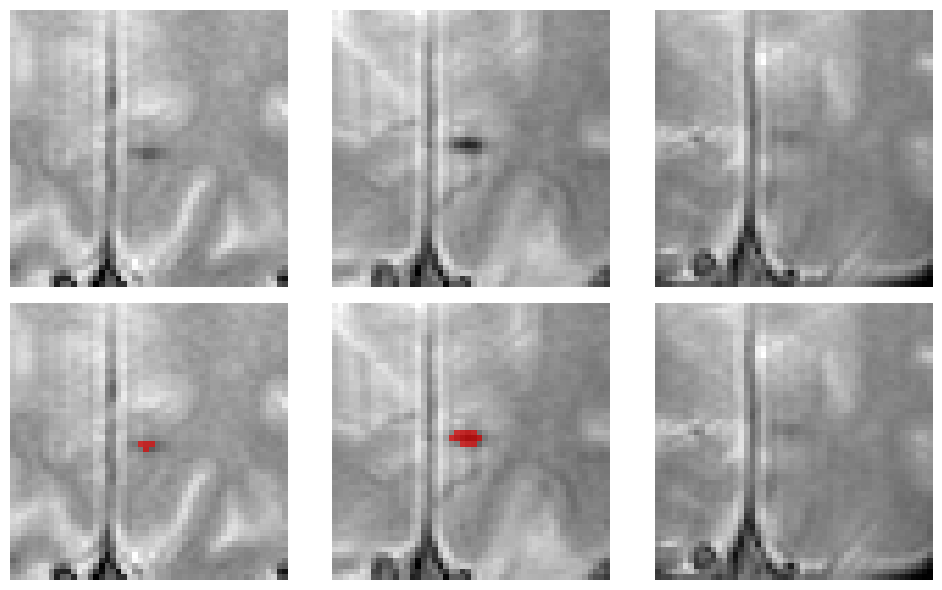

In [31]:
import os
import random
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

# Ruta al dataset generado
OUTPUT_DIR = "/media/PORT-DISK/Practicas/nnUNet_raw_ADNI/Dataset201_SyntheticCMB" 
DATASET_PATH = OUTPUT_DIR  # ya definida en tu script

def get_random_lesion_bbox(label):
    coords = np.array(np.where(label > 0))
    
    if coords.shape[1] == 0:
        return None
    
    # Elegimos una lesión aleatoria
    idx = np.random.randint(coords.shape[1])
    x, y, z = coords[:, idx]
    
    return x, y, z


def crop_zoom_exact(img, lbl, center, window=25):
    cx, cy, cz = map(int, center)
    
    x_s, x_e = max(0, cx-window), min(img.shape[0], cx+window)
    y_s, y_e = max(0, cy-window), min(img.shape[1], cy+window)
    
    img_crop = img[x_s:x_e, y_s:y_e, :]
    lbl_crop = lbl[x_s:x_e, y_s:y_e, :]
    
    return img_crop, lbl_crop


def normalize(patch):
    return (patch - np.min(patch)) / (np.max(patch) - np.min(patch) + 1e-8)


def plot_triplet_exact(img_crop, lbl_crop, z_center):
    slices = [z_center-1, z_center, z_center+1]
    
    fig, axes = plt.subplots(2, 3, figsize=(10, 6))
    
    for i, z in enumerate(slices):
        if z < 0 or z >= img_crop.shape[2]:
            continue
        
        img_slice = normalize(img_crop[:, :, z])
        lbl_slice = lbl_crop[:, :, z]
        
        # 🔹 SOLO IMAGEN (igual que tu pipeline)
        axes[0, i].imshow(np.rot90(img_slice), cmap='gray')
        axes[0, i].axis('off')
        
        # 🔹 IMAGEN + MÁSCARA
        axes[1, i].imshow(np.rot90(img_slice), cmap='gray')
        axes[1, i].imshow(
            np.ma.masked_where(np.rot90(lbl_slice) == 0, np.rot90(lbl_slice)),
            cmap='autumn',
            alpha=0.6
        )
        axes[1, i].axis('off')
    
    axes[0, 0].set_ylabel("Imagen", fontsize=12)
    axes[1, 0].set_ylabel("Imagen + Mask", fontsize=12)
    
    plt.tight_layout()
    plt.show()

def show_zoom_example(split="Tr"):
    images_dir = os.path.join(DATASET_PATH, f"images{split}")
    labels_dir = os.path.join(DATASET_PATH, f"labels{split}")
    
    cases = sorted([f for f in os.listdir(images_dir) if f.endswith("_0000.nii.gz")])
    
    while True:
        case = random.choice(cases)
        subject_id = case.replace("_0000.nii.gz", "")
        
        img_path = os.path.join(images_dir, case)
        lbl_path = os.path.join(labels_dir, f"{subject_id}.nii.gz")
        
        nii_img = nib.load(img_path)
        nii_lbl = nib.load(lbl_path)
        
        img = nii_img.get_fdata()
        lbl = nii_lbl.get_fdata()
        
        center = get_random_lesion_bbox(lbl)
        
        if center is None:
            continue  # saltar casos sin lesión
        
        print(f"\nCaso: {subject_id} | Lesión en {center}")

        img_crop, lbl_crop = crop_zoom_exact(img, lbl, center, window=25)
        
        # Ajustar z al nuevo sistema
        z_center = center[2]
        
        plot_triplet_exact(img_crop, lbl_crop, z_center)
        break

# ==========================
# EJECUCIÓN
# ==========================
for _ in range(15):
    show_zoom_example(split="Tr")